In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Recreate the Day 18 fraud dataset

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "transaction_amount": np.random.randint(100, 50000, n),
    "transaction_frequency": np.random.randint(1, 20, n),
    "account_age_days": np.random.randint(30, 3000, n),
    "international": np.random.randint(0, 2, n),
    "failed_attempts": np.random.randint(0, 6, n)
})

data["fraud"] = (
    ((data["transaction_amount"] > 30000) &
     (data["failed_attempts"] >= 3)) |
    ((data["international"] == 1) &
     (data["transaction_frequency"] > 12))
).astype(int)

noise = np.random.choice(n, size=120, replace=False)
data.loc[noise, "fraud"] = 1 - data.loc[noise, "fraud"]

print(data.head())
print("\nDataset shape:", data.shape)
print("\nFraud counts:")
print(data["fraud"].value_counts())

   transaction_amount  transaction_frequency  account_age_days  international  \
0               15895                     19               169              0   
1                 960                     12              1454              0   
2               38258                     18              2979              1   
3               44832                      6               546              0   
4               11384                     18              2646              1   

   failed_attempts  fraud  
0                4      0  
1                0      0  
2                1      1  
3                2      0  
4                2      1  

Dataset shape: (2000, 6)

Fraud counts:
fraud
0    1269
1     731
Name: count, dtype: int64


In [3]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [4]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [5]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.Collecting xgboost
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     -------------------------------------- 0.0/101.7 MB 103.4 kB/s eta 0:16:23
     -------------------------------------- 0.0/101.7 MB 103.4 kB/s eta 0:16:23
     ---------------------


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------- ---------------------- 39.0/101.7 MB 480.3 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 480.0 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 478.9 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 478.2 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 478.2 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 478.2 kB/s eta 0:02:11
     -------------- ---------------------- 39.1/101.7 MB 478.2 kB/s eta 0:02:11
     -------------- ---------------------- 39.2/101.7 MB 477.6 kB/s eta 0:02:11
     -------------- ---------------------- 39.2/101.7 MB 476.8 kB/s eta 0:02:11
     -------------- ---------------------- 39.3/101.7 MB 475.8 kB/s eta 0:02:12
     -------------- ---------------------- 39.3/101.7 MB 475.8 kB/s eta 0:02:12
     -------------- ---------------------- 39.3/101.7 MB 474.8 kB/s eta 0:02:12
     -------------- --------------------

In [1]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [5]:
X = data.drop("fraud", axis=1)
y = data["fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Features shape: (2000, 5)
Target shape: (2000,)

Features:
['transaction_amount', 'transaction_frequency', 'account_age_days', 'international', 'failed_attempts']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1600, 5)
Testing features: (400, 5)
Training target: (1600,)
Testing target: (400,)


In [7]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [8]:
y_pred_xgb = xgb_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_xgb[:20])

First 20 predictions:
[0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1]


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9175

Confusion Matrix:
[[237  17]
 [ 16 130]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       254
           1       0.88      0.89      0.89       146

    accuracy                           0.92       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.92      0.92      0.92       400



In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.925


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.925


In [12]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

comparison["Accuracy_Percentage"] = comparison["Accuracy"] * 100

print(comparison)

           Model  Accuracy  Accuracy_Percentage
0  Random Forest    0.9250                92.50
1        XGBoost    0.9175                91.75


In [13]:
xgb_progress = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_progress.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = xgb_progress.evals_result()

print("Training rounds recorded:", len(results["validation_0"]["logloss"]))
print("Initial training logloss:", results["validation_0"]["logloss"][0])
print("Final training logloss:", results["validation_0"]["logloss"][-1])
print("Initial test logloss:", results["validation_1"]["logloss"][0])
print("Final test logloss:", results["validation_1"]["logloss"][-1])

Training rounds recorded: 100
Initial training logloss: 0.6071006242372096
Final training logloss: 0.14129705714047305
Initial test logloss: 0.610394384264946
Final test logloss: 0.30349406879628077


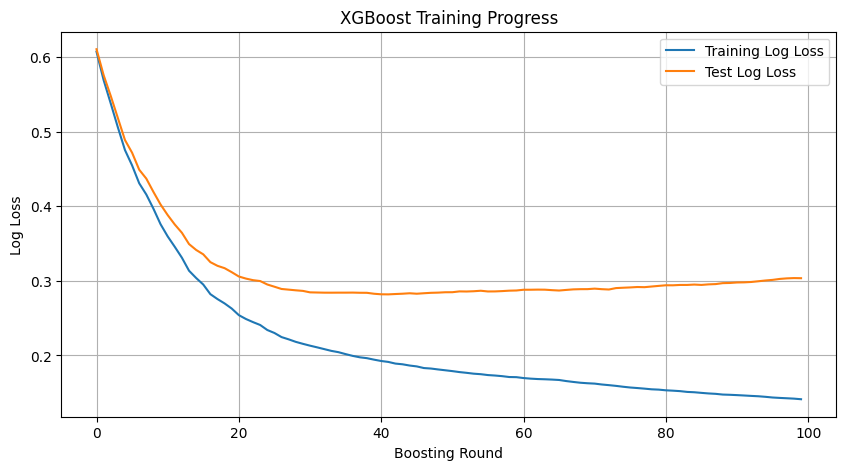

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    results["validation_0"]["logloss"],
    label="Training Log Loss"
)

plt.plot(
    results["validation_1"]["logloss"],
    label="Test Log Loss"
)

plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("XGBoost Training Progress")
plt.legend()
plt.grid(True)

plt.show()


In [15]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


                 Feature  Importance
3          international    0.423830
4        failed_attempts    0.264653
1  transaction_frequency    0.142608
0     transaction_amount    0.131082
2       account_age_days    0.037827


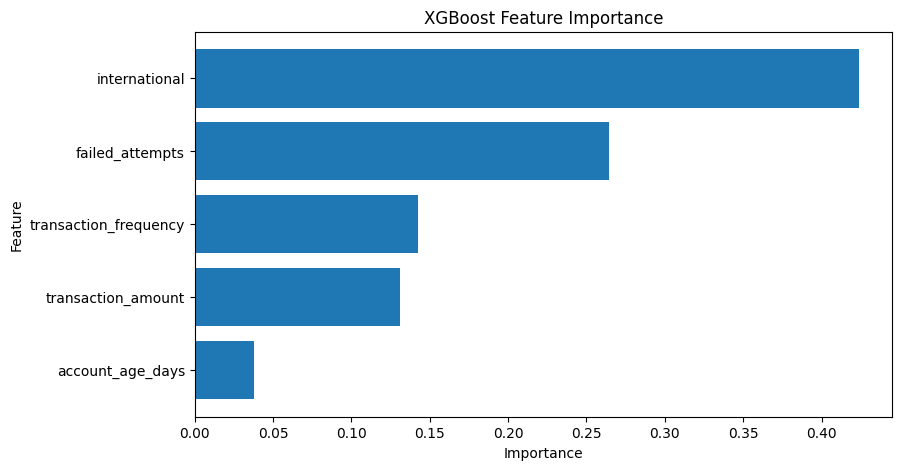

In [16]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()


In [17]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

comparison["Accuracy_Percentage"] = comparison["Accuracy"] * 100

comparison["Difference_from_XGBoost"] = (
    comparison["Accuracy"] - xgb_accuracy
) * 100

print(comparison)

           Model  Accuracy  Accuracy_Percentage  Difference_from_XGBoost
0  Random Forest    0.9250                92.50                     0.75
1        XGBoost    0.9175                91.75                     0.00


In [18]:
comparison.to_csv("day19_model_comparison.csv", index=False)

print("Saved: day19_model_comparison.csv")

Saved: day19_model_comparison.csv


In [19]:
feature_importance.to_csv(
    "day19_xgboost_feature_importance.csv",
    index=False
)

print("Saved: day19_xgboost_feature_importance.csv")

Saved: day19_xgboost_feature_importance.csv


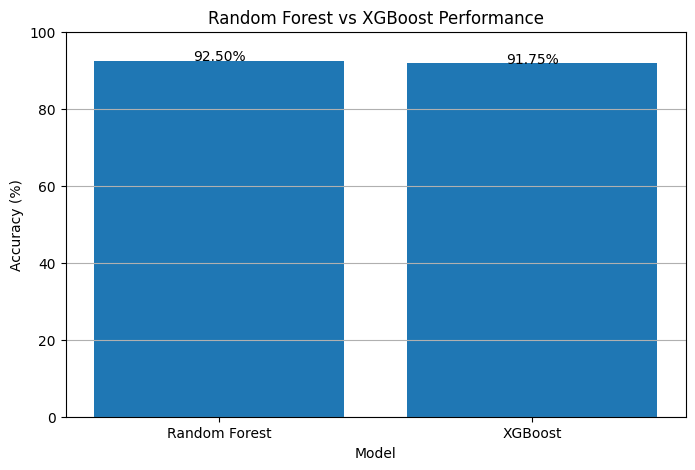

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy_Percentage"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Random Forest vs XGBoost Performance")

for i, value in enumerate(comparison["Accuracy_Percentage"]):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.ylim(0, 100)
plt.grid(axis="y")

plt.show()


## XGBoost Advantages and Trade-offs

### Advantages

1. **High predictive performance**
   - XGBoost combines many weak decision trees sequentially.
   - Each new tree tries to reduce the errors made by previous trees.

2. **Handles complex relationships**
   - It can learn nonlinear relationships between input features.
   - This is useful for problems such as fraud detection and customer prediction.

3. **Regularization**
   - XGBoost includes techniques that help control model complexity and reduce overfitting.

4. **Flexible and tunable**
   - Parameters such as learning rate, tree depth, number of trees, subsampling, and feature sampling can be adjusted.

5. **Works well with tabular data**
   - XGBoost is widely used for structured/tabular machine-learning problems.

### Trade-offs

1. **More hyperparameters**
   - XGBoost has many parameters that need to be selected carefully.

2. **Risk of overfitting**
   - Increasing the number of trees or tree complexity too much can cause the model to fit training data better than unseen data.

3. **More computational complexity**
   - Boosting trains trees sequentially, making the process more complex than simply building independent trees.

4. **Requires tuning**
   - Good performance often depends on choosing appropriate values for learning rate, tree depth, number of estimators, and other parameters.

### Experiment Conclusion

In this fraud-detection experiment:

- Random Forest Accuracy: **92.50%**
- XGBoost Accuracy: **91.75%**
- Random Forest performed **0.75 percentage points better**.

Therefore, XGBoost did not outperform Random Forest with the selected parameters on this dataset. However, the XGBoost learning curve showed that boosting progressively reduced training loss, while the test loss began increasing after approximately 30–40 boosting rounds, indicating some overfitting.

In [21]:
test_logloss = results["validation_1"]["logloss"]

best_round = np.argmin(test_logloss) + 1
best_test_logloss = test_logloss[best_round - 1]

print("Best boosting round:", best_round)
print("Lowest test logloss:", best_test_logloss)

Best boosting round: 42
Lowest test logloss: 0.28183239463018256


In [22]:
training_progress = pd.DataFrame({
    "Boosting_Round": range(1, 101),
    "Training_LogLoss": results["validation_0"]["logloss"],
    "Test_LogLoss": results["validation_1"]["logloss"]
})

training_progress.to_csv(
    "day19_xgboost_training_progress.csv",
    index=False
)

print("Saved: day19_xgboost_training_progress.csv")

Saved: day19_xgboost_training_progress.csv
